НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ

[1/6] Загружаем данные из Excel...
Файл успешно загружен! Найдено 56 записей

Первые 5 записей из файла:
   Площадь  Количество комнат       Этаж     Район        Состояние     Цена
0       45                  2    средний     Центр       евроремонт  3950000
1       70                  3    средний     Центр  требует ремонта  2720000
2       91                  3    средний     Центр          хорошее  7500000
3       44                  2    средний  Северный       евроремонт  3500000
4       35                  1  последний     Южный          хорошее  2250000

Названия столбцов в файле:
['Площадь', 'Количество комнат', 'Этаж', 'Район', 'Состояние', 'Цена']
Столбец 'Количество комнат' переименован в 'Комнат'

Обновленные названия столбцов:
['Площадь', 'Комнат', 'Этаж', 'Район', 'Состояние', 'Цена']

[2/6] Проводим анализ данных...

Информация о данных:
- Размер набора: (56, 6)
- Столбцы: ['Площадь', 'Комнат', 'Этаж', 'Район', 'Состояние', 'Цена']

Типы данных:
П

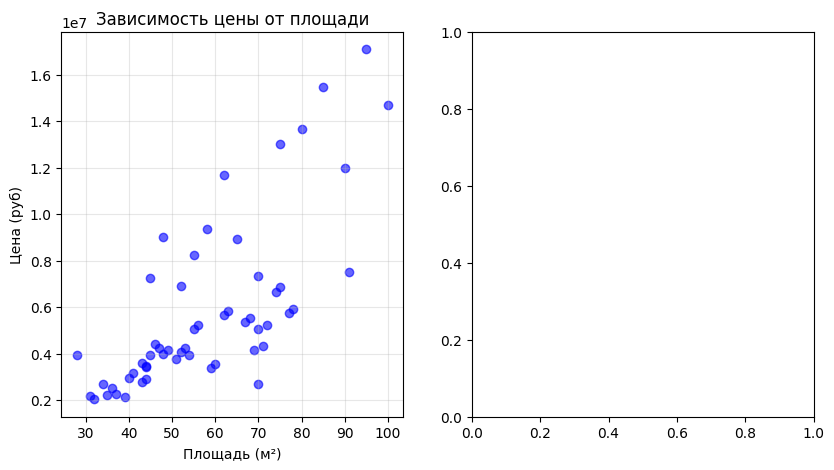

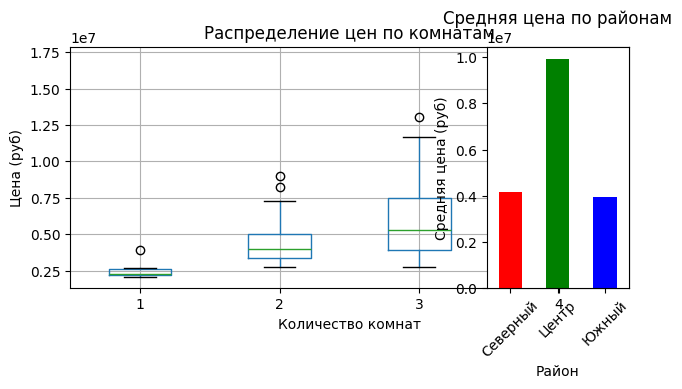

Графики сохранены в файл 'analysis_plots.png'

[3/6] Подготавливаем данные для модели...
Признаки (X): (56, 5)
Целевая переменная (y): (56,)

Числовые признаки: ['Площадь', 'Комнат']
Категориальные признаки: ['Этаж', 'Район', 'Состояние']

[4/6] Разделяем данные на обучающую и тестовую выборки...
Обучающая выборка: (44, 5)
Тестовая выборка: (12, 5)

[5/6] Создаем и обучаем модель...
Модель успешно обучена!

[6/6] Оцениваем качество модели...

КАЧЕСТВО МОДЕЛИ НА ОБУЧАЮЩИХ ДАННЫХ:
R² (коэффициент детерминации): 0.8715
MAE (средняя ошибка): 882,905 руб.
RMSE (среднекв. ошибка): 1,329,744 руб.
Относительная ошибка: 15.2%

КАЧЕСТВО МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ:
R² (коэффициент детерминации): 0.6449
MAE (средняя ошибка): 1,312,699 руб.
RMSE (среднекв. ошибка): 1,903,512 руб.
Относительная ошибка: 21.6%


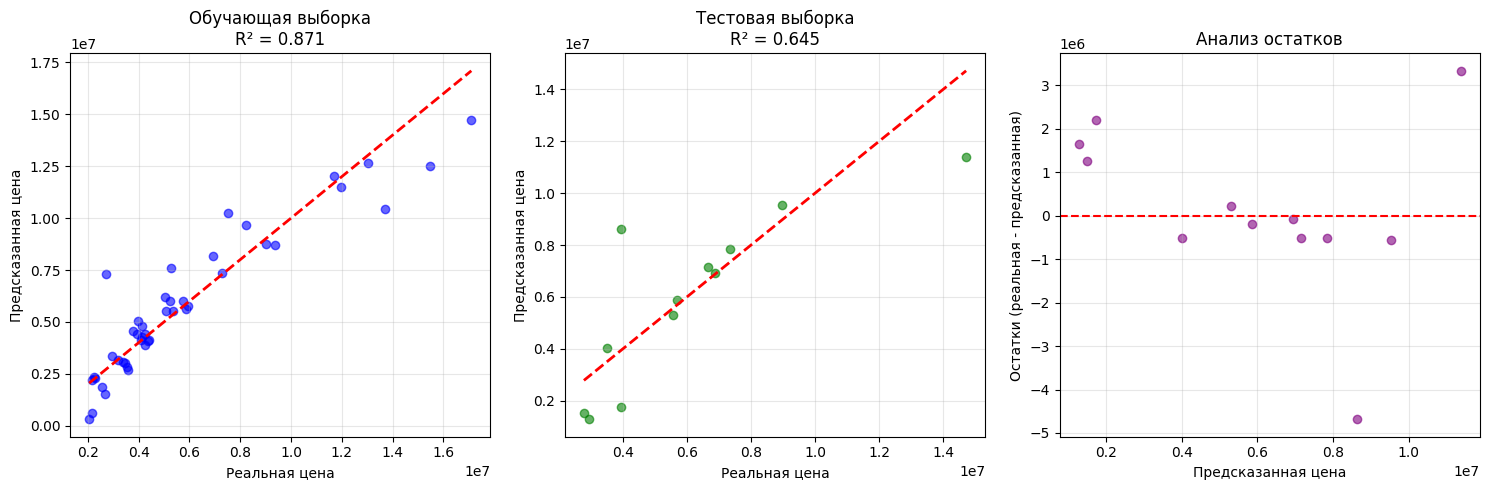

Графики результатов сохранены в файл 'model_results.png'

СОХРАНЕНИЕ МОДЕЛИ
Модель сохранена в файл 'flat_price_model.pkl'
Информация о модели сохранена в 'model_info.pkl'

ОБУЧЕНИЕ ЗАВЕРШЕНО УСПЕШНО!


In [ ]:
# train_model.py
# Этот файл нужно запустить один раз для обучения и сохранения модели

# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ")
print("=" * 50)

# ШАГ 1: ЗАГРУЗКА ДАННЫХ ИЗ EXCEL
print("\n[1/6] Загружаем данные из Excel...")

# Указываем путь к файлу Excel
file_path = "Книга1.xlsx"  # Файл лежит в той же папке, что и программа

# Загружаем данные из Excel
try:
    df = pd.read_excel(file_path)
    print(f"Файл успешно загружен! Найдено {len(df)} записей")
except FileNotFoundError:
    print(f"Ошибка: Файл '{file_path}' не найден!")
    print("Убедитесь, что файл лежит в той же папке, что и программа")
    exit()

# Покажем первые несколько строк для проверки
print("\nПервые 5 записей из файла:")
print(df.head())

# Проверим названия столбцов
print("\nНазвания столбцов в файле:")
print(df.columns.tolist())

# ВАЖНО: Переименовываем столбец 'цена' в 'Цена' для совместимости с кодом
if 'цена' in df.columns:
    df.rename(columns={'цена': 'Цена'}, inplace=True)
    print("\nСтолбец 'цена' переименован в 'Цена'")

# Проверяем, что столбец 'Количество комнат' называется правильно
if 'Количество комнат' in df.columns:
    df.rename(columns={'Количество комнат': 'Комнат'}, inplace=True)
    print("Столбец 'Количество комнат' переименован в 'Комнат'")

print("\nОбновленные названия столбцов:")
print(df.columns.tolist())

# ШАГ 2: РАЗВЕДОВАТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ
print("\n[2/6] Проводим анализ данных...")
print(f"\nИнформация о данных:")
print(f"- Размер набора: {df.shape}")
print(f"- Столбцы: {list(df.columns)}")

# Проверяем типы данных
print(f"\nТипы данных:")
print(df.dtypes)

# Проверяем наличие пропусков
print(f"\nПропуски в данных:")
print(df.isnull().sum())

# Статистика по числовым столбцам
print(f"\nСтатистика по числовым столбцам:")
print(df.describe())

# Визуализация зависимостей
print("\nСоздаем графики для анализа...")

# График 1: Зависимость цены от площади
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(df['Площадь'], df['Цена'], alpha=0.6, color='blue')
plt.xlabel('Площадь (м²)')
plt.ylabel('Цена (руб)')
plt.title('Зависимость цены от площади')
plt.grid(True, alpha=0.3)

# График 2: Зависимость цены от количества комнат
plt.subplot(1, 3, 2)
df.boxplot(column='Цена', by='Комнат')
plt.title('Распределение цен по комнатам')
plt.suptitle('')
plt.xlabel('Количество комнат')
plt.ylabel('Цена (руб)')

# График 3: Средние цены по районам
plt.subplot(1, 3, 3)
df.groupby('Район')['Цена'].mean().plot(kind='bar', color=['red', 'green', 'blue'])
plt.title('Средняя цена по районам')
plt.xlabel('Район')
plt.ylabel('Средняя цена (руб)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('analysis_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("Графики сохранены в файл 'analysis_plots.png'")

# ШАГ 3: ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ
print("\n[3/6] Подготавливаем данные для модели...")

# Разделяем признаки и целевую переменную
X = df.drop('Цена', axis=1)
y = df['Цена']

print(f"Признаки (X): {X.shape}")
print(f"Целевая переменная (y): {y.shape}")

# Определяем числовые и категориальные признаки
numeric_features = ['Площадь', 'Комнат']
categorical_features = ['Этаж', 'Район', 'Состояние']

print(f"\nЧисловые признаки: {numeric_features}")
print(f"Категориальные признаки: {categorical_features}")

# Создаем препроцессор для обработки данных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# ШАГ 4: РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
print("\n[4/6] Разделяем данные на обучающую и тестовую выборки...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

# ШАГ 5: СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ
print("\n[5/6] Создаем и обучаем модель...")

# Создаем пайплайн: сначала обработка данных, потом линейная регрессия
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
model.fit(X_train, y_train)

print("Модель успешно обучена!")

# ШАГ 6: ОЦЕНКА МОДЕЛИ
print("\n[6/6] Оцениваем качество модели...")

# Предсказания на обучающей выборке
y_train_pred = model.predict(X_train)

# Предсказания на тестовой выборке
y_pred = model.predict(X_test)

# Метрики для обучающей выборки
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("\n" + "=" * 30)
print("КАЧЕСТВО МОДЕЛИ НА ОБУЧАЮЩИХ ДАННЫХ:")
print("=" * 30)
print(f"R² (коэффициент детерминации): {train_r2:.4f}")
print(f"MAE (средняя ошибка): {train_mae:,.0f} руб.")
print(f"RMSE (среднекв. ошибка): {train_rmse:,.0f} руб.")
print(f"Относительная ошибка: {train_mae / y_train.mean() * 100:.1f}%")

# Метрики для тестовой выборки
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "=" * 30)
print("КАЧЕСТВО МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ:")
print("=" * 30)
print(f"R² (коэффициент детерминации): {test_r2:.4f}")
print(f"MAE (средняя ошибка): {test_mae:,.0f} руб.")
print(f"RMSE (среднекв. ошибка): {test_rmse:,.0f} руб.")
print(f"Относительная ошибка: {test_mae / y_test.mean() * 100:.1f}%")

# Визуализация результатов
plt.figure(figsize=(15, 5))

# График 1: Предсказанные vs Реальные значения (обучающая выборка)
plt.subplot(1, 3, 1)
plt.scatter(y_train, y_train_pred, alpha=0.6, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title(f'Обучающая выборка\nR² = {train_r2:.3f}')
plt.grid(True, alpha=0.3)

# График 2: Предсказанные vs Реальные значения (тестовая выборка)
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title(f'Тестовая выборка\nR² = {test_r2:.3f}')
plt.grid(True, alpha=0.3)

# График 3: Остатки (разница между реальной и предсказанной ценой)
plt.subplot(1, 3, 3)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанная цена')
plt.ylabel('Остатки (реальная - предсказанная)')
plt.title('Анализ остатков')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Графики результатов сохранены в файл 'model_results.png'")

# ШАГ 7: СОХРАНЕНИЕ МОДЕЛИ
print("\n" + "=" * 50)
print("СОХРАНЕНИЕ МОДЕЛИ")
print("=" * 50)

# Сохраняем модель в файл
joblib.dump(model, 'flat_price_model.pkl')
print("Модель сохранена в файл 'flat_price_model.pkl'")

# Сохраняем информацию о модели
model_info = {
    'r2_train': train_r2,
    'r2_test': test_r2,
    'mae_train': train_mae,
    'mae_test': test_mae,
    'rmse_train': train_rmse,
    'rmse_test': test_rmse,
    'train_size': len(X_train),
    'test_size': len(X_test)
}

joblib.dump(model_info, 'model_info.pkl')
print("Информация о модели сохранена в 'model_info.pkl'")

print("\n" + "=" * 50)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО УСПЕШНО!")
print("=" * 50)